# Compare Memory-Based Versus Generator-Based Data Loading

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 1

**Objective:** Compare memory-based (bulk) and generator-based (sequential /
on-demand) strategies for loading a satellite / geospatial image dataset,
in terms of implementation complexity, memory footprint, and I/O
performance, for an agricultural vs. non-agricultural land classification
problem.

**Dataset:** `images_dataSAT` — real Sentinel-2 satellite tiles (64x64 RGB
`.jpg`), organized as:
* `images_dataSAT/class_0_non_agri/` — 3,000 images
* `images_dataSAT/class_1_agri/` — 3,000 images

> **Note:** if your JupyterLab environment downloads this dataset via a
> `wget` / `skillsnetwork.prepare_url()` cell rather than having it already
> present, run that download/unzip cell first so that `images_dataSAT/`
> exists in your working directory before running the rest of this
> notebook.


## 1. Import libraries and packages

In [1]:
# Core libraries
import os
import time
import tracemalloc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("NumPy version:", np.__version__)


NumPy version: 2.4.4


## 2. Download data

The dataset should already be extracted into a folder named
`images_dataSAT/`, with two class subfolders. We simply point to it below.
If you need to download/unzip it first, do that here (replace this cell
with your environment's actual download cell) before continuing.


In [2]:
DATA_DIR = Path("images_dataSAT")

assert DATA_DIR.exists(), (
    f"'{DATA_DIR}' not found. Download/unzip the dataset into the working "
    "directory before continuing."
)

class_dirs = {
    "non_agricultural": DATA_DIR / "class_0_non_agri",
    "agricultural": DATA_DIR / "class_1_agri",
}

for name, path in class_dirs.items():
    n_files = len(list(path.glob("*.jpg")))
    print(f"{name:<18} -> {path}  ({n_files} images)")


non_agricultural   -> images_dataSAT/class_0_non_agri  (3000 images)
agricultural       -> images_dataSAT/class_1_agri  (3000 images)


## 3. Load images

We compare two strategies for getting these images ready for a model:

1. **Memory-based (bulk) loading** — read *every* image into a single
   NumPy array up front, before training starts.
2. **Generator-based (sequential / on-demand) loading** — keep only the
   file *paths* in memory, and open each image lazily, one batch at a
   time, only when it's actually needed.

For each strategy we measure:
* **Wall-clock time** to become "ready" (bulk: fully loaded; generator:
  first batch produced)
* **Peak memory used**, via Python's built-in `tracemalloc`


In [3]:
all_paths = sorted(class_dirs["agricultural"].glob("*.jpg")) + \
            sorted(class_dirs["non_agricultural"].glob("*.jpg"))
all_labels = (
    [1] * len(list(class_dirs["agricultural"].glob("*.jpg"))) +
    [0] * len(list(class_dirs["non_agricultural"].glob("*.jpg")))
)  # 1 = agricultural, 0 = non-agricultural

print(f"Total image paths collected: {len(all_paths)}")


Total image paths collected: 6000


### 3a. Memory-based (bulk) loading

In [4]:
def load_all_into_memory(paths, target_size=(64, 64)):
    """Load every image fully into a single NumPy array (bulk / memory-based)."""
    images = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        if img.size != target_size:
            img = img.resize(target_size)
        images.append(np.asarray(img, dtype=np.uint8))
    return np.stack(images)

tracemalloc.start()
t0 = time.perf_counter()

bulk_images = load_all_into_memory(all_paths)

t1 = time.perf_counter()
current, bulk_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

bulk_time = t1 - t0
print(f"Bulk loading complete.")
print(f"  Shape: {bulk_images.shape}")
print(f"  Time to load ALL images: {bulk_time:.3f} s")
print(f"  Peak memory during loading: {bulk_peak_mem / (1024**2):.2f} MB")
print(f"  Array size in memory: {bulk_images.nbytes / (1024**2):.2f} MB")


Bulk loading complete.
  Shape: (6000, 64, 64, 3)
  Time to load ALL images: 2.961 s
  Peak memory during loading: 143.13 MB
  Array size in memory: 70.31 MB


### 3b. Generator-based (sequential / on-demand) loading

In [5]:
def image_generator(paths, labels, target_size=(64, 64), batch_size=32):
    """Yield one batch of images at a time, reading from disk on demand.
    Only file paths are held in memory up front -- pixel data is created
    lazily and discarded (garbage-collected) after each batch is consumed.
    """
    n = len(paths)
    idx = 0
    while idx < n:
        batch_paths = paths[idx: idx + batch_size]
        batch_labels = labels[idx: idx + batch_size]
        batch_images = np.stack([
            np.asarray(Image.open(p).convert("RGB"), dtype=np.uint8)
            for p in batch_paths
        ])
        yield batch_images, np.array(batch_labels)
        idx += batch_size

tracemalloc.start()
t0 = time.perf_counter()

gen = image_generator(all_paths, all_labels, batch_size=32)
first_batch_images, first_batch_labels = next(gen)  # only pulls ONE batch

t1 = time.perf_counter()
current, gen_peak_mem_first_batch = tracemalloc.get_traced_memory()
tracemalloc.stop()

gen_time_first_batch = t1 - t0
print(f"Generator ready to use after first batch.")
print(f"  First batch shape: {first_batch_images.shape}")
print(f"  Time to produce FIRST batch: {gen_time_first_batch:.4f} s")
print(f"  Peak memory after first batch: {gen_peak_mem_first_batch / (1024**2):.2f} MB")


Generator ready to use after first batch.
  First batch shape: (32, 64, 64, 3)
  Time to produce FIRST batch: 0.0115 s
  Peak memory after first batch: 0.77 MB


In [6]:
# For a fair full-pass comparison, also time a full pass through the generator
# (this simulates what happens over the course of one training epoch).
tracemalloc.start()
t0 = time.perf_counter()

gen_full = image_generator(all_paths, all_labels, batch_size=32)
n_batches = 0
for batch_images, batch_labels in gen_full:
    n_batches += 1
    del batch_images, batch_labels  # simulate the batch being consumed/discarded by training

t1 = time.perf_counter()
current, gen_peak_mem_full_pass = tracemalloc.get_traced_memory()
tracemalloc.stop()

gen_time_full_pass = t1 - t0
print(f"Full generator pass complete ({n_batches} batches).")
print(f"  Time for full pass (one epoch's worth of I/O): {gen_time_full_pass:.3f} s")
print(f"  Peak memory during full pass: {gen_peak_mem_full_pass / (1024**2):.2f} MB")


Full generator pass complete (188 batches).
  Time for full pass (one epoch's worth of I/O): 1.729 s
  Peak memory during full pass: 1.15 MB


## 4. Compare results

Two different, equally valid comparisons:

* **"Ready to start training" time** — bulk loading pays the full I/O cost
  up front; the generator only pays for one batch before training can
  begin.
* **Peak memory** — bulk loading must hold the *entire* dataset in RAM at
  once; the generator only ever holds one batch.


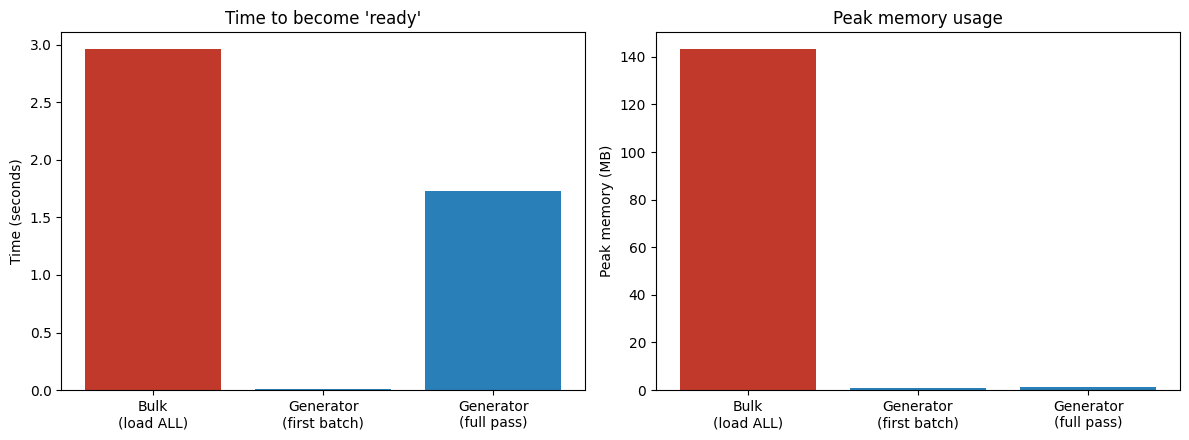

Strategy              Time (s)    Peak Mem (MB)  
-------------------------------------------------
Bulk (all images)     2.961       143.13         
Generator (1 batch)   0.0115      0.77           
Generator (full pass) 1.729       1.15           


In [7]:
labels_x = ["Bulk\n(load ALL)", "Generator\n(first batch)", "Generator\n(full pass)"]
times = [bulk_time, gen_time_first_batch, gen_time_full_pass]
mems = [bulk_peak_mem / (1024**2), gen_peak_mem_first_batch / (1024**2), gen_peak_mem_full_pass / (1024**2)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(labels_x, times, color=["#c0392b", "#2980b9", "#2980b9"])
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title("Time to become 'ready'")

axes[1].bar(labels_x, mems, color=["#c0392b", "#2980b9", "#2980b9"])
axes[1].set_ylabel("Peak memory (MB)")
axes[1].set_title("Peak memory usage")

plt.tight_layout()
plt.show()

print(f"{'Strategy':<22}{'Time (s)':<12}{'Peak Mem (MB)':<15}")
print("-" * 49)
print(f"{'Bulk (all images)':<22}{bulk_time:<12.3f}{bulk_peak_mem/(1024**2):<15.2f}")
print(f"{'Generator (1 batch)':<22}{gen_time_first_batch:<12.4f}{gen_peak_mem_first_batch/(1024**2):<15.2f}")
print(f"{'Generator (full pass)':<22}{gen_time_full_pass:<12.3f}{gen_peak_mem_full_pass/(1024**2):<15.2f}")


## 5. Visualize sample images

A quick sanity check that both loading paths produce the same underlying
data, and that the agricultural / non-agricultural labelling is sensible.


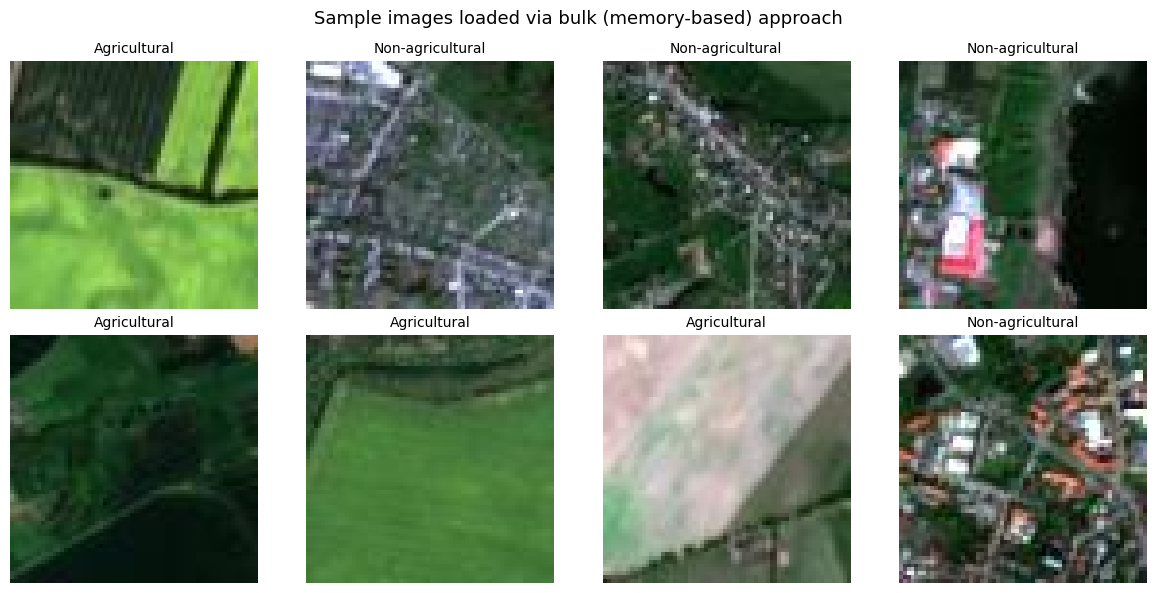

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
rng = np.random.default_rng(42)
sample_idxs = rng.choice(len(bulk_images), size=8, replace=False)

for ax, i in zip(axes.flat, sample_idxs):
    ax.imshow(bulk_images[i])
    label_str = "Agricultural" if all_labels[i] == 1 else "Non-agricultural"
    ax.set_title(label_str, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample images loaded via bulk (memory-based) approach", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Discussion — trade-offs

**Q: When would you prefer memory-based (bulk) loading?**
When the full dataset comfortably fits in RAM, and you want the
simplicity of indexing directly into a NumPy array (e.g. small
datasets, quick prototyping, repeated random access for shuffling). At
6,000 tiny 64x64 images (~25 MB on disk), this dataset is actually small
enough that bulk loading is very feasible.

**Q: When would you prefer generator-based (on-demand) loading?**
When the dataset is large (or will grow), doesn't fit in memory, or
when you're training on a machine with limited RAM/VRAM. Generators
trade a small, roughly constant, per-batch time and memory cost for the
ability to scale to arbitrarily large datasets — which is why
production pipelines (`tf.data`, PyTorch `DataLoader`) are built around
this pattern.

**Q: What did the measurements above actually show?**
* Bulk loading's peak memory scales with the **size of the whole
  dataset**.
* The generator's peak memory stays roughly **constant**, regardless of
  how many images exist in total — only `batch_size` matters.
* Bulk loading pays its full time cost once, up front; the generator
  pays a similar *total* time cost over a full pass, but spread out, and
  lets training begin almost immediately after the first batch.
